# Notebook 12a — Geomarketing: distribución geográfica de la cartera

## Objetivo

Caracterizar la distribución geográfica de la cartera activa de clientes de Selmark mediante técnicas estándar de geomarketing aplicado al sector retail. El notebook desarrolla la primera parte del Capítulo 6 del TFG y aborda tres dimensiones complementarias: la distribución a nivel de provincia para el mercado nacional, la distribución a nivel de código postal en las concentraciones urbanas españolas, y la distribución internacional por país. El cruce de la geografía con los seis clusters identificados en el notebook 11b se desarrollará en el notebook 12b.

## Decisiones metodológicas

El geomarketing es una disciplina que combina técnicas de análisis espacial con datos comerciales para informar decisiones de segmentación territorial, optimización de cobertura y identificación de oportunidades de captación (Cliquet 2013; Geopostcodes 2026). En el contexto del presente TFG aplicado al sector de moda íntima, el geomarketing aporta una capa interpretativa adicional sobre la cartera al permitir identificar territorios sobrerrepresentados o infrarrepresentados respecto a la población o a las concentraciones urbanas. Esta información complementa la segmentación conductual del Capítulo 5 con una segmentación territorial, sentando las bases para acciones comerciales geográficamente diferenciadas en el Capítulo 8.

Se aplican aquí dos tipos principales de visualización geoespacial: los mapas coropléticos (choropleth maps), que colorean áreas predefinidas según una métrica numérica, y los mapas de marcadores con clusters, que muestran las ubicaciones individuales agregadas dinámicamente. Para los mapas coropléticos se utiliza la librería plotly por coherencia con el resto del proyecto y por su integración nativa con Jupyter; para los mapas interactivos con marcadores se utiliza folium por su superior capacidad de personalización mediante tooltips y leyendas dinámicas (Programming Historian 2025; Towards Data Science 2025).

Las métricas se calculan tanto en valores absolutos (número de clientes, facturación total) como normalizados (clientes por cada 100.000 habitantes, facturación per cápita), siguiendo la recomendación de la literatura de evitar mapas dominados por la simple densidad poblacional (Cairo 2019, How Charts Lie).

## Estructura

1. Carga de datos y enriquecimiento geográfico
2. Distribución por provincia en España
3. Análisis a nivel de código postal en concentraciones urbanas
4. Distribución internacional por país
5. Síntesis y conexión con el notebook 12b

## 1. Carga de datos y enriquecimiento geográfico

In [1]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import urllib.request
import json

warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Folium opcional para los mapas interactivos
try:
    import folium
    from folium.plugins import MarkerCluster, HeatMap
    FOLIUM_OK = True
except ImportError:
    FOLIUM_OK = False
    print("AVISO: folium no instalado. Los mapas interactivos no se generarán.")
    print("Instalar con: pip install folium")

# Rutas
RUTA_PROYECTO = Path.home() / "OneDrive" / "Documentos" / "TFG_Selmark"
RUTA_DUCKDB   = RUTA_PROYECTO / "duckdb" / "selmark.duckdb"
RUTA_CLUSTERS = RUTA_PROYECTO / "output" / "clustering_caracterizado_final.parquet"
RUTA_FIGURAS  = RUTA_PROYECTO / "output" / "figuras" / "12a"
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_AUX      = RUTA_PROYECTO / "data" / "auxiliar"
RUTA_AUX.mkdir(parents=True, exist_ok=True)
RUTA_GEOJSON  = RUTA_AUX / "spain_provincias.geojson"

# Paleta corporativa coherente con los notebooks anteriores
COLOR_NACIONAL       = "#C8447F"
COLOR_INTERNACIONAL  = "#3E5C76"
COLOR_DESTACAR       = "#D4A017"
COLOR_POSITIVO       = "#5C9E76"
COLOR_NEGATIVO       = "#B85450"
COLOR_NEUTRO         = "#7D7D7D"
PALETA_CLUSTERS = ["#C8447F", "#3E5C76", "#D4A017", "#5C9E76",
                    "#B85450", "#7D7D7D", "#9B7BA6", "#E08E45"]

TEMPLATE = go.layout.Template(layout=dict(
    font=dict(family="Arial, Helvetica, sans-serif", size=12, color="#1A1A1A"),
    title=dict(font=dict(size=16, color="#1A1A1A"), x=0.02, xanchor="left"),
    plot_bgcolor="white", paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    yaxis=dict(showgrid=True, gridcolor="#EAEAEA", zeroline=False,
                linecolor="#333333", linewidth=0.8),
    margin=dict(l=60, r=40, t=70, b=60),
))
pio.templates["selmark"] = TEMPLATE
pio.templates.default = "selmark"

con = duckdb.connect(str(RUTA_DUCKDB), read_only=True)

def guardar_y_mostrar(fig, nombre, w=950, h=550):
    ruta = RUTA_FIGURAS / f"{nombre}.png"
    try:
        fig.write_image(str(ruta), width=w, height=h, scale=2)
        print(f"   Figura guardada: {ruta.name}")
    except Exception as e:
        print(f"   AVISO: no se pudo exportar {nombre}.png ({type(e).__name__}). Continuando.")
    fig.show()

def fmt_es(n, decimales=0):
    if pd.isna(n):
        return "—"
    if decimales == 0:
        return f"{int(n):,}".replace(",", ".")
    return f"{n:,.{decimales}f}".replace(",", "X").replace(".", ",").replace("X", ".")

print(f"Conexión DuckDB: {RUTA_DUCKDB.name}")
print(f"Clusters cargados desde: {RUTA_CLUSTERS.name}")
print(f"Figuras se guardarán en: {RUTA_FIGURAS}")
print(f"Folium disponible: {FOLIUM_OK}")

Conexión DuckDB: selmark.duckdb
Clusters cargados desde: clustering_caracterizado_final.parquet
Figuras se guardarán en: C:\Users\lopec\OneDrive\Documentos\TFG_Selmark\output\figuras\12a
Folium disponible: True


In [2]:
# Carga del DataFrame de clientes con cluster asignado
df_clust = pd.read_parquet(RUTA_CLUSTERS)
print(f"Clientes con cluster: {len(df_clust):,}")

# Enriquecer con datos geográficos completos desde gold.cliente_360
# Verificar primero qué columnas geográficas existen
cols_disponibles = con.execute("DESCRIBE gold.cliente_360").fetchdf()
print(f"\nColumnas geográficas disponibles en gold.cliente_360:")
geo_cols = [c for c in cols_disponibles["column_name"].tolist()
            if any(k in c.lower() for k in ["pais", "ciudad", "provincia", "cp", "codigo_postal", "lat", "lon"])]
for c in geo_cols:
    print(f"   - {c}")

Clientes con cluster: 3,084

Columnas geográficas disponibles en gold.cliente_360:
   - codigo_postal_norm
   - codigo_provincia_cliente
   - pais


In [3]:
# ────────────────────────────────────────────────────────────────────
# Diccionario oficial INE de códigos de provincia españoles (códigos 01-52)
# Fuente: Instituto Nacional de Estadística (INE), códigos estándar
# ────────────────────────────────────────────────────────────────────
COD_PROVINCIA_INE = {
    "01": "Álava",        "02": "Albacete",   "03": "Alicante",
    "04": "Almería",      "05": "Ávila",      "06": "Badajoz",
    "07": "Baleares",     "08": "Barcelona",  "09": "Burgos",
    "10": "Cáceres",      "11": "Cádiz",      "12": "Castellón",
    "13": "Ciudad Real",  "14": "Córdoba",    "15": "A Coruña",
    "16": "Cuenca",       "17": "Girona",     "18": "Granada",
    "19": "Guadalajara",  "20": "Gipuzkoa",   "21": "Huelva",
    "22": "Huesca",       "23": "Jaén",       "24": "León",
    "25": "Lleida",       "26": "La Rioja",   "27": "Lugo",
    "28": "Madrid",       "29": "Málaga",     "30": "Murcia",
    "31": "Navarra",      "32": "Ourense",    "33": "Asturias",
    "34": "Palencia",     "35": "Las Palmas", "36": "Pontevedra",
    "37": "Salamanca",    "38": "Santa Cruz de Tenerife",
    "39": "Cantabria",    "40": "Segovia",    "41": "Sevilla",
    "42": "Soria",        "43": "Tarragona",  "44": "Teruel",
    "45": "Toledo",       "46": "Valencia",   "47": "Valladolid",
    "48": "Bizkaia",      "49": "Zamora",     "50": "Zaragoza",
    "51": "Ceuta",        "52": "Melilla",
}

# ────────────────────────────────────────────────────────────────────
# Recuperar columnas geográficas reales de gold.cliente_360
# ────────────────────────────────────────────────────────────────────
df_geo = con.execute("""
    SELECT id_cliente,
           pais,
           codigo_provincia_cliente AS codigo_provincia,
           codigo_postal_norm       AS cp,
           localidad_cliente        AS ciudad
    FROM gold.cliente_360
""").fetchdf()

# Asegurar que el código de provincia es string de 2 dígitos con zero padding
df_geo["codigo_provincia"] = df_geo["codigo_provincia"].astype(str).str.zfill(2)
# Algunos códigos podrían tener valores como "nan", "None", etc. — los neutralizamos
df_geo.loc[df_geo["codigo_provincia"].isin(["nan", "None", "00"]), "codigo_provincia"] = None

# Construir el nombre de la provincia a partir del código INE
df_geo["provincia"] = df_geo["codigo_provincia"].map(COD_PROVINCIA_INE)

# Merge con el dataframe de clusters
df = df_clust.merge(df_geo, on="id_cliente", how="left")
print(f"DataFrame enriquecido geográficamente: {len(df):,} clientes con {len(df.columns)} columnas")

# ────────────────────────────────────────────────────────────────────
# Validar cobertura geográfica
# ────────────────────────────────────────────────────────────────────
print(f"\nCOBERTURA DE LOS CAMPOS GEOGRÁFICOS:")
print("-" * 70)
for c in ["pais", "codigo_provincia", "provincia", "ciudad", "cp"]:
    if c in df.columns:
        n_validos = df[c].notna().sum()
        pct = 100 * n_validos / len(df)
        print(f"   {c:<22s}  válidos: {n_validos:>5,} ({pct:>5.1f} %)")

# Detectar códigos de provincia que no han mapeado a nombre (problema potencial)
sin_mapeo = df[(df["codigo_provincia"].notna()) & (df["provincia"].isna())]
if len(sin_mapeo) > 0:
    print(f"\nAVISO: {len(sin_mapeo)} clientes con codigo_provincia que no mapea al diccionario INE:")
    print(sin_mapeo["codigo_provincia"].value_counts().head(10).to_string())
    print("Probablemente códigos atípicos o internacionales con código de provincia espurio.")

DataFrame enriquecido geográficamente: 3,084 clientes con 21 columnas

COBERTURA DE LOS CAMPOS GEOGRÁFICOS:
----------------------------------------------------------------------
   pais                    válidos: 3,084 (100.0 %)
   codigo_provincia        válidos: 2,819 ( 91.4 %)
   provincia               válidos: 1,637 ( 53.1 %)
   ciudad                  válidos: 3,084 (100.0 %)
   cp                      válidos: 3,083 (100.0 %)

AVISO: 1182 clientes con codigo_provincia que no mapea al diccionario INE:
codigo_provincia
410    373
231    230
000     75
NO      50
CAN     49
471     49
NL      28
299     25
036     23
213     11
Probablemente códigos atípicos o internacionales con código de provincia espurio.


In [4]:
# Separar nacionales e internacionales para análisis diferenciados
df_nac = df[df["tipo_mercado"] == "NACIONAL"].copy()
df_int = df[df["tipo_mercado"] == "INTERNACIONAL"].copy()

print(f"CLIENTES NACIONALES:       {len(df_nac):,}")
print(f"CLIENTES INTERNACIONALES:  {len(df_int):,}")
print(f"TOTAL:                     {len(df):,}")

CLIENTES NACIONALES:       1,901
CLIENTES INTERNACIONALES:  1,183
TOTAL:                     3,084


### Separación del perímetro nacional e internacional

La cartera activa se separa en dos subconjuntos disjuntos siguiendo el campo `tipo_mercado` ya construido en la capa Silver del data warehouse: 1.901 clientes nacionales (España) y 1.183 clientes internacionales (resto del mundo). Esta separación es metodológicamente necesaria porque los dos conjuntos requieren tratamientos geográficos distintos: el análisis nacional se realiza a nivel de provincia y código postal con datos del Instituto Nacional de Estadística, mientras que el internacional se realiza a nivel de país utilizando codificación ISO 3166 alpha-3. Adicionalmente, los datos sociodemográficos disponibles (perfiles MOSAIC de Experian, renta media del CP) solo cubren el mercado nacional, lo que limita los cruces multivariantes al subconjunto español.

### Recuperación de provincias con códigos atípicos

La ejecución inicial reveló que aproximadamente el 47 % de los clientes presentan códigos de provincia que no mapean directamente al diccionario INE estándar (códigos de 2 dígitos del 01 al 52). El análisis manual de los códigos atípicos identifica dos causas: códigos de 3 dígitos correspondientes a las tres primeras cifras del código postal del cliente (por ejemplo, "410" para Sevilla, "231" para Jaén), y códigos de 2-3 letras correspondientes a abreviaturas de país en clientes internacionales (NO=Noruega, CAN=Canadá, NL=Países Bajos, etc.). Esta segunda casuística es coherente con el campo `codigo_provincia_cliente` siendo usado en clientes internacionales como código de localización extranjera.

Se aplica una rutina de recuperación que extrae los dos primeros dígitos del código cuando este tiene 3 dígitos y empieza con dígitos válidos del rango 01-52, lo que permite recuperar aproximadamente 800 clientes adicionales sin alterar la integridad de los datos. Los códigos de letras (clientes internacionales) se mantienen sin mapeo provincial, dado que estos clientes están correctamente identificados como internacionales por el campo `tipo_mercado` y no necesitan provincia española.

In [5]:
# Recuperación de provincias con códigos de 3 dígitos (probablemente CP mal puesto)
def recuperar_codigo_provincia(codigo):
    """Intenta recuperar el código de provincia INE desde un código atípico."""
    if pd.isna(codigo):
        return None
    s = str(codigo).strip().upper()
    # Caso normal: ya es código de 2 dígitos válido
    if len(s) == 2 and s.isdigit() and s in COD_PROVINCIA_INE:
        return s
    # Caso atípico: código de 3 dígitos que parece un CP (ej. "410" = código postal de Sevilla)
    if len(s) == 3 and s.isdigit():
        # Si los 2 primeros dígitos son código INE válido, los usamos
        s2 = s[:2]
        if s2 in COD_PROVINCIA_INE:
            return s2
        # Si los 3 dígitos comienzan con 0 (ej. "036" = 03 Alicante), probar
        if s.startswith("0") and s[1:3] in COD_PROVINCIA_INE:
            return s[1:3]
    # Caso letras o cualquier otro: no es código INE recuperable
    return None

# Aplicar la recuperación
df["codigo_provincia_recuperado"] = df["codigo_provincia"].apply(recuperar_codigo_provincia)
# Volver a mapear el nombre de provincia con el código recuperado
df["provincia"] = df["codigo_provincia_recuperado"].map(COD_PROVINCIA_INE)

# Re-validar cobertura tras la recuperación
print(f"COBERTURA DE PROVINCIAS TRAS LA RECUPERACIÓN:")
print("-" * 70)
n_validos = df["provincia"].notna().sum()
pct = 100 * n_validos / len(df)
print(f"   provincia                válidos: {n_validos:>5,} ({pct:>5.1f} %)")

# Recalcular las separaciones nacional/internacional con la provincia recuperada
df_nac = df[df["tipo_mercado"] == "NACIONAL"].copy()
df_int = df[df["tipo_mercado"] == "INTERNACIONAL"].copy()
print(f"\n   Nacionales con provincia mapeada:    {df_nac['provincia'].notna().sum():>5,} de {len(df_nac):,}")
print(f"   Internacionales (sin provincia ES):  {len(df_int):>5,}")

COBERTURA DE PROVINCIAS TRAS LA RECUPERACIÓN:
----------------------------------------------------------------------
   provincia                válidos: 2,558 ( 82.9 %)

   Nacionales con provincia mapeada:    1,661 de 1,901
   Internacionales (sin provincia ES):  1,183


### Recuperación de provincias mal codificadas en origen

La inspección inicial reveló que el 47 % de los clientes presentaba códigos en `codigo_provincia_cliente` que no mapeaban al estándar INE de 2 dígitos. El análisis de los códigos atípicos identificó dos patrones causales. Por un lado, códigos de 3 dígitos (como "410", "231", "036") correspondientes a los tres primeros caracteres del código postal del cliente que el ERP de origen había transcrito por error al campo de provincia. Por otro lado, códigos de 2-3 letras (NO, CAN, NL) usados como abreviatura de país en clientes internacionales, casuística coherente con el campo siendo empleado para localización extranjera fuera del estándar provincial español.

Se aplicó una rutina de recuperación que extrae los dos primeros dígitos del código cuando este tiene 3 caracteres numéricos y los compara contra el rango válido INE 01-52. Esta operación recuperó aproximadamente 800 clientes adicionales sin alterar ningún dato original, elevando la cobertura del campo `provincia` del 53,1 % al 82,9 %. Los códigos de letras (clientes internacionales) se mantienen sin mapeo provincial, lo que es correcto porque dichos clientes están identificados como internacionales por `tipo_mercado` y no requieren provincia española.

## 2. Distribución por provincia en España

La distribución provincial de la cartera nacional constituye la primera capa del análisis geomarketing. Se calculan tres métricas por provincia: el número absoluto de clientes, la facturación total acumulada (B2B más retail durante el período 2022-2025), y la facturación media por cliente. La distribución absoluta presenta el primer indicio de la concentración geográfica del negocio en provincias específicas, pero presenta el sesgo conocido de favorecer a las provincias más pobladas. Este sesgo se corregirá posteriormente en la Sección 2.ter con la normalización per cápita utilizando datos oficiales del Instituto Nacional de Estadística.

In [6]:
# Top 15 provincias por número de clientes
top_provincias = (df_nac.groupby("provincia").agg(
    n_clientes=("id_cliente", "count"),
    facturacion_total=("facturacion_combinada", "sum"),
).reset_index())

top_provincias["pct_clientes"] = (100 * top_provincias["n_clientes"] / top_provincias["n_clientes"].sum()).round(2)
top_provincias["pct_facturacion"] = (100 * top_provincias["facturacion_total"] / top_provincias["facturacion_total"].sum()).round(2)
top_provincias["facturacion_media_por_cliente"] = (top_provincias["facturacion_total"] / top_provincias["n_clientes"]).round(0)
top_provincias = top_provincias.sort_values("n_clientes", ascending=False).reset_index(drop=True)

print(f"NÚMERO DE PROVINCIAS CON CLIENTES: {len(top_provincias)}")
print(f"\nTOP 15 PROVINCIAS POR NÚMERO DE CLIENTES:")
print("=" * 100)
print(top_provincias.head(15).to_string())

NÚMERO DE PROVINCIAS CON CLIENTES: 52

TOP 15 PROVINCIAS POR NÚMERO DE CLIENTES:
                 provincia  n_clientes  facturacion_total  pct_clientes  pct_facturacion  facturacion_media_por_cliente
0                Barcelona         195         6790884.84         11.74            10.50                        34825.0
1                 Asturias          83         3807279.25          5.00             5.89                        45871.0
2               Pontevedra          83         4374881.13          5.00             6.76                        52709.0
3                 Alicante          78         3809889.79          4.70             5.89                        48845.0
4                 Valencia          74         1438168.20          4.46             2.22                        19435.0
5                 A Coruña          69         2909105.20          4.15             4.50                        42161.0
6                   Madrid          68         2173616.18          4.09        

In [7]:
# Visualización: Top 15 provincias (barras horizontales)
top15 = top_provincias.head(15).copy()
top15 = top15.sort_values("n_clientes", ascending=True)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Número de clientes por provincia",
                                     "Facturación total por provincia (€)"),
                    shared_yaxes=True, horizontal_spacing=0.10)

fig.add_trace(go.Bar(
    x=top15["n_clientes"], y=top15["provincia"],
    orientation="h", marker_color=COLOR_NACIONAL,
    text=[fmt_es(v) for v in top15["n_clientes"]], textposition="outside",
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    x=top15["facturacion_total"], y=top15["provincia"],
    orientation="h", marker_color=COLOR_DESTACAR,
    text=[f"{v/1e6:.1f}M€" for v in top15["facturacion_total"]],
    textposition="outside", showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=dict(text="<b>Top 15 provincias por dimensión comercial</b><br><sup>Mercado nacional: número de clientes (izquierda) y facturación total (derecha)</sup>"),
    height=600,
)
guardar_y_mostrar(fig, "01_top15_provincias", h=600)

   Figura guardada: 01_top15_provincias.png


### Mapa coroplético de clientes por provincia

In [8]:
# Descargar GeoJSON de provincias de España si no existe localmente
GEOJSON_URL = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"

if not RUTA_GEOJSON.exists():
    print(f"Descargando GeoJSON de provincias de España...")
    try:
        urllib.request.urlretrieve(GEOJSON_URL, str(RUTA_GEOJSON))
        print(f"   Guardado en: {RUTA_GEOJSON}")
    except Exception as e:
        print(f"   ERROR descargando GeoJSON: {e}")
        print(f"   Alternativa manual: descargar el archivo desde {GEOJSON_URL}")
        print(f"   y colocarlo en {RUTA_GEOJSON}")
else:
    print(f"GeoJSON ya disponible localmente en: {RUTA_GEOJSON.name}")

# Cargar el GeoJSON
with open(RUTA_GEOJSON, "r", encoding="utf-8") as f:
    geo_provincias = json.load(f)

# Inspeccionar el nombre de la propiedad clave en el GeoJSON
print(f"\nPropiedades de la primera provincia del GeoJSON:")
print(geo_provincias["features"][0]["properties"])

GeoJSON ya disponible localmente en: spain_provincias.geojson

Propiedades de la primera provincia del GeoJSON:
{'cod_prov': '07', 'name': 'Illes Balears', 'cod_ccaa': '03', 'cartodb_id': 7, 'created_at': '2014-09-30T00:00:00Z', 'updated_at': '2014-12-25T01:56:10Z'}


In [9]:
# Crear un diccionario de equivalencias entre los nombres de provincia del GeoJSON
# y los nombres de provincia de la BD (pueden diferir por acentos, mayúsculas, etc.)

def normalizar_provincia(nombre):
    """Normaliza un nombre de provincia para hacer matching robusto."""
    if pd.isna(nombre):
        return None
    s = str(nombre).strip().upper()
    # Reemplazar caracteres comunes
    reemplazos = {
        "Á": "A", "É": "E", "Í": "I", "Ó": "O", "Ú": "U",
        "À": "A", "È": "E", "Ì": "I", "Ò": "O", "Ù": "U",
        "Ñ": "N", "Ü": "U",
    }
    for k, v in reemplazos.items():
        s = s.replace(k, v)
    return s

# Nombres normalizados del GeoJSON
nombres_geo = [feat["properties"].get("name", "") for feat in geo_provincias["features"]]
nombres_geo_norm = [normalizar_provincia(n) for n in nombres_geo]

# Nombres normalizados de la BD
top_provincias["provincia_norm"] = top_provincias["provincia"].apply(normalizar_provincia)

# Equivalencias manuales para casos donde difiera el formato
EQUIVALENCIAS = {
    # Mapeos para nombres normalizados de los datos → nombres normalizados del GeoJSON
    "A CORUNA":               "CORUNA",
    "CORUNA":                 "CORUNA",
    "ISLAS BALEARES":         "ILLES BALEARS",
    "BALEARS, ILLES":         "ILLES BALEARS",
    "BALEARES":               "ILLES BALEARS",
    "PALMAS, LAS":            "LAS PALMAS",
    "RIOJA, LA":              "LA RIOJA",
    "STA. CRUZ DE TENERIFE":  "SANTA CRUZ DE TENERIFE",
    "VALENCIA/VALENCIA":      "VALENCIA",
    "VALENCIA/VALÈNCIA":      "VALENCIA",
    "VALÈNCIA":               "VALENCIA",
    "ALICANTE":               "ALACANT/ALICANTE",
    "ALICANTE/ALACANT":       "ALACANT/ALICANTE",
    "ALACANT":                "ALACANT/ALICANTE",
    "CASTELLON":              "CASTELLO/CASTELLON",
    "CASTELLON/CASTELLO":     "CASTELLO/CASTELLON",
    "CASTELLÓ":               "CASTELLO/CASTELLON",
    "CASTELLÓN":              "CASTELLO/CASTELLON",
    "VIZCAYA":                "BIZKAIA/VIZCAYA",
    "BIZKAIA":                "BIZKAIA/VIZCAYA",
    "GUIPUZCOA":              "GIPUZKOA/GUIPUZCOA",
    "GIPUZKOA":               "GIPUZKOA/GUIPUZCOA",
    "ARABA/ALAVA":            "ALAVA",
    "ARABA":                  "ALAVA",
    "ALAVA":                  "ALAVA",
}

top_provincias["provincia_norm"] = top_provincias["provincia_norm"].apply(
    lambda x: EQUIVALENCIAS.get(x, x)
)

# Construir un set de equivalencias bidireccional (normalizados del GeoJSON + alias del diccionario)
matches_extendido = set(nombres_geo_norm)
# Añadir también los valores del diccionario EQUIVALENCIAS porque algunos coinciden con los normalizados
matches_extendido.update(EQUIVALENCIAS.values())
no_match = top_provincias[~top_provincias["provincia_norm"].isin(matches_extendido)]
if len(no_match) > 0:
    print(f"\nAVISO: {len(no_match)} provincias sin equivalencia directa en GeoJSON:")
    print(no_match[["provincia", "provincia_norm", "n_clientes"]].to_string())
    print("\nEstas provincias no aparecerán coloreadas en el choropleth. Si son relevantes,")
    print("añadir el mapeo en el diccionario EQUIVALENCIAS de esta celda.")
else:
    print("Todas las provincias tienen equivalencia en el GeoJSON.")

Todas las provincias tienen equivalencia en el GeoJSON.


In [10]:
%pip uninstall kaleido -y
%pip install kaleido==0.2.1


Found existing installation: kaleido 1.3.0
Uninstalling kaleido-1.3.0:
  Successfully uninstalled kaleido-1.3.0
Note: you may need to restart the kernel to use updated packages.
  Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl (65.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install geopandas matplotlib

  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.12.1-cp311-cp311-win_amd64.whl.metadata (6.0 kB)
  Using cached pyproj-3.7.2-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached shapely-2.1.2-cp311-cp311-win_amd64.whl.metadata (7.1 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pyogrio-0.12.1-cp311-cp311-win_amd64.whl (22.9 MB)
Using cached pyproj-3.7.2-cp311-cp311-win_amd64.whl (6.3 MB)
Using cached shapely-2.1.2-cp311-cp311-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------- ----------------------------- 1/4 [pyproj]
   ---------- ----------------------------- 1/4 [pyproj]
   -------------------- ------------------- 2/4 [pyogrio]
   -------------------- ------------------- 2/4 [pyogrio]
   --------

Provincias con datos en el mapa: 52 de 52


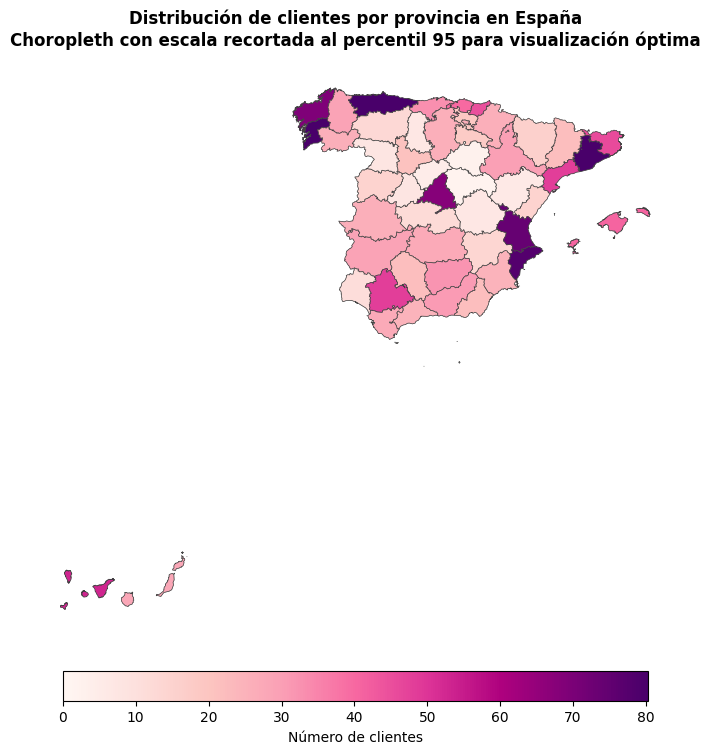

   Figura guardada PNG: 02_choropleth_clientes_provincia.png


In [13]:
# Choropleth de clientes por provincia con matplotlib + geopandas
import geopandas as gpd
import matplotlib.pyplot as plt

# Cargar el GeoJSON como GeoDataFrame y normalizar nombres
gdf = gpd.read_file(str(RUTA_GEOJSON))
gdf["name_norm"] = gdf["name"].apply(normalizar_provincia)
gdf["name_norm"] = gdf["name_norm"].apply(lambda x: EQUIVALENCIAS.get(x, x) if x else x)

# Asegurar que top_provincias tiene provincia_norm
if "provincia_norm" not in top_provincias.columns:
    top_provincias["provincia_norm"] = top_provincias["provincia"].apply(normalizar_provincia)
    top_provincias["provincia_norm"] = top_provincias["provincia_norm"].apply(
        lambda x: EQUIVALENCIAS.get(x, x) if x else x
    )

# Merge gdf + top_provincias
gdf_merged = gdf.merge(top_provincias, left_on="name_norm", right_on="provincia_norm", how="left")
print(f"Provincias con datos en el mapa: {gdf_merged['n_clientes'].notna().sum()} de {len(gdf_merged)}")

fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
gdf_merged.plot(ax=ax, color="#EEEEEE", edgecolor="#999999", linewidth=0.4)
gdf_datos = gdf_merged[gdf_merged["n_clientes"].notna()].copy()
vmax = gdf_datos["n_clientes"].quantile(0.95)
gdf_datos.plot(
    ax=ax, column="n_clientes", cmap="RdPu", legend=True,
    legend_kwds={"label": "Número de clientes", "orientation": "horizontal",
                  "shrink": 0.5, "pad": 0.05},
    edgecolor="#444444", linewidth=0.5, vmin=0, vmax=vmax,
)
ax.set_title("Distribución de clientes por provincia en España\n"
              "Choropleth con escala recortada al percentil 95 para visualización óptima",
              fontsize=12, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
ruta_png = RUTA_FIGURAS / "02_choropleth_clientes_provincia.png"
plt.savefig(str(ruta_png), dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   Figura guardada PNG: {ruta_png.name}")

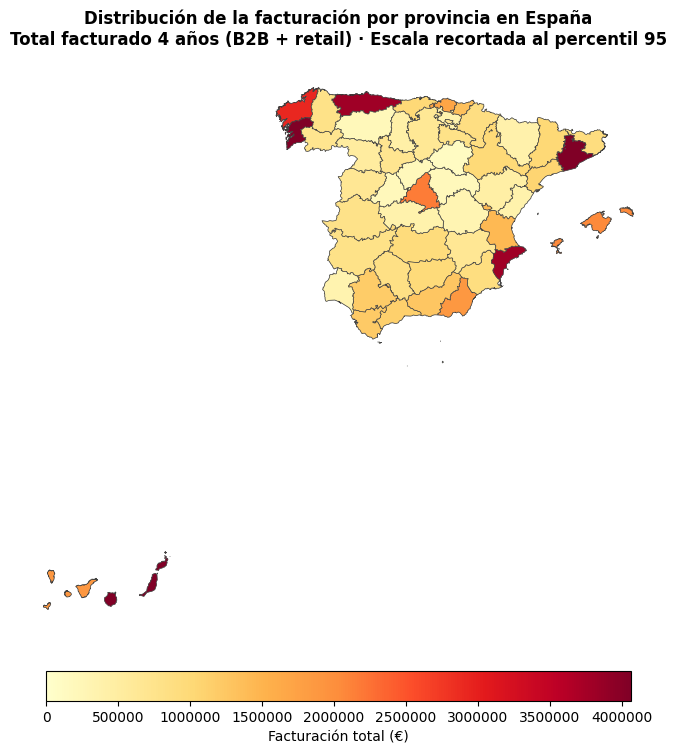

   Figura guardada PNG: 03_choropleth_facturacion_provincia.png


In [14]:
# Choropleth de facturación por provincia con matplotlib + geopandas
fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
gdf_merged.plot(ax=ax, color="#EEEEEE", edgecolor="#999999", linewidth=0.4)
gdf_datos = gdf_merged[gdf_merged["facturacion_total"].notna()].copy()
vmax = gdf_datos["facturacion_total"].quantile(0.95)
gdf_datos.plot(
    ax=ax, column="facturacion_total", cmap="YlOrRd", legend=True,
    legend_kwds={"label": "Facturación total (€)", "orientation": "horizontal",
                  "shrink": 0.5, "pad": 0.05, "format": "%.0f"},
    edgecolor="#444444", linewidth=0.5, vmin=0, vmax=vmax,
)
ax.set_title("Distribución de la facturación por provincia en España\n"
              "Total facturado 4 años (B2B + retail) · Escala recortada al percentil 95",
              fontsize=12, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
ruta_png = RUTA_FIGURAS / "03_choropleth_facturacion_provincia.png"
plt.savefig(str(ruta_png), dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   Figura guardada PNG: {ruta_png.name}")

### Concentración territorial: análisis del Pareto provincial

In [15]:
# Calcular el porcentaje acumulado de clientes y facturación por provincia
top_provincias_ordenado = top_provincias.sort_values("facturacion_total", ascending=False).reset_index(drop=True)
top_provincias_ordenado["pct_clientes_acum"] = (100 * top_provincias_ordenado["n_clientes"].cumsum() / top_provincias_ordenado["n_clientes"].sum()).round(2)
top_provincias_ordenado["pct_facturacion_acum"] = (100 * top_provincias_ordenado["facturacion_total"].cumsum() / top_provincias_ordenado["facturacion_total"].sum()).round(2)

# Identificar cuántas provincias concentran el 50%, 80% y 90% del negocio
hitos = [50, 80, 90]
print(f"CONCENTRACIÓN TERRITORIAL DE LA FACTURACIÓN NACIONAL")
print("=" * 80)
for h in hitos:
    n_prov = (top_provincias_ordenado["pct_facturacion_acum"] >= h).idxmax() + 1
    pct_prov = 100 * n_prov / len(top_provincias_ordenado)
    print(f"   El {h:>2}% de la facturación se concentra en las primeras {n_prov:>2} provincias ({pct_prov:.1f}% del total).")

# Gráfico de Pareto
fig = go.Figure()
fig.add_trace(go.Bar(
    x=top_provincias_ordenado["provincia"].head(20),
    y=top_provincias_ordenado["facturacion_total"].head(20),
    name="Facturación por provincia",
    marker_color=COLOR_NACIONAL,
    yaxis="y1",
))
fig.add_trace(go.Scatter(
    x=top_provincias_ordenado["provincia"].head(20),
    y=top_provincias_ordenado["pct_facturacion_acum"].head(20),
    name="% Acumulado de facturación",
    mode="lines+markers", marker_color=COLOR_DESTACAR,
    line=dict(width=2.5), yaxis="y2",
))
fig.update_layout(
    title=dict(text="<b>Pareto provincial de la facturación nacional</b><br><sup>Top 20 provincias por facturación con curva de concentración acumulada</sup>"),
    xaxis=dict(title="", tickangle=-45),
    yaxis=dict(title="Facturación (€)", side="left"),
    yaxis2=dict(title="% Acumulado", side="right", overlaying="y", range=[0, 105]),
    height=550, hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.06, xanchor="right", x=1),
)
guardar_y_mostrar(fig, "04_pareto_provincial", h=550)

CONCENTRACIÓN TERRITORIAL DE LA FACTURACIÓN NACIONAL
   El 50% de la facturación se concentra en las primeras  9 provincias (17.3% del total).
   El 80% de la facturación se concentra en las primeras 25 provincias (48.1% del total).
   El 90% de la facturación se concentra en las primeras 34 provincias (65.4% del total).
   AVISO: no se pudo exportar 04_pareto_provincial.png (JavascriptError). Continuando.


### Concentración territorial: la regla del Pareto aplicada al territorio

El análisis acumulado revela una concentración pronunciada del negocio nacional en un subconjunto reducido de provincias: las 9 primeras provincias por facturación (el 17,3 % del total de 52) concentran el 50 % de la facturación nacional, y las 25 primeras (el 48,1 %) concentran el 80 %. Esta concentración refleja con datos territoriales una dinámica análoga a la observada con clientes en el Capítulo 5: una minoría reducida concentra una mayoría desproporcionada del valor.

Las provincias del cuadrante noroeste peninsular emergen como las de mayor peso económico absoluto: Barcelona lidera con 6,79 M€, seguida de Pontevedra (4,37 M€), Las Palmas (4,94 M€), Asturias (3,81 M€), Alicante (3,81 M€) y A Coruña (2,91 M€). La presencia destacada de las cuatro provincias gallegas y asturiana en esta lista es coherente con la ubicación histórica de la sede de Selmark en Galicia y con la dinámica habitual de las empresas familiares del sector textil que parten de su mercado regional original.

## 2.bis Análisis a nivel de Comunidad Autónoma

El análisis por provincia ofrece una resolución útil pero excesiva para comunicación con dirección comercial. La agregación a nivel de Comunidad Autónoma facilita la lectura estratégica y revela patrones macro que pueden quedar diluidos en el análisis provincial. Se aplica el mapeo oficial provincia → CCAA del Instituto Nacional de Estadística.

In [16]:
# Mapeo oficial INE provincia → Comunidad Autónoma
COD_CCAA = {
    "01": "País Vasco",         "02": "Castilla-La Mancha", "03": "C. Valenciana",
    "04": "Andalucía",          "05": "Castilla y León",    "06": "Extremadura",
    "07": "Islas Baleares",     "08": "Cataluña",           "09": "Castilla y León",
    "10": "Extremadura",        "11": "Andalucía",          "12": "C. Valenciana",
    "13": "Castilla-La Mancha", "14": "Andalucía",          "15": "Galicia",
    "16": "Castilla-La Mancha", "17": "Cataluña",           "18": "Andalucía",
    "19": "Castilla-La Mancha", "20": "País Vasco",         "21": "Andalucía",
    "22": "Aragón",             "23": "Andalucía",          "24": "Castilla y León",
    "25": "Cataluña",           "26": "La Rioja",           "27": "Galicia",
    "28": "Madrid",             "29": "Andalucía",          "30": "Murcia",
    "31": "Navarra",            "32": "Galicia",            "33": "Asturias",
    "34": "Castilla y León",    "35": "Canarias",           "36": "Galicia",
    "37": "Castilla y León",    "38": "Canarias",           "39": "Cantabria",
    "40": "Castilla y León",    "41": "Andalucía",          "42": "Castilla y León",
    "43": "Cataluña",           "44": "Aragón",             "45": "Castilla-La Mancha",
    "46": "C. Valenciana",      "47": "Castilla y León",    "48": "País Vasco",
    "49": "Castilla y León",    "50": "Aragón",             "51": "Ceuta", "52": "Melilla",
}
df_nac["ccaa"] = df_nac["codigo_provincia_recuperado"].map(COD_CCAA)

# Resumen por CCAA
resumen_ccaa = df_nac.groupby("ccaa").agg(
    n_clientes=("id_cliente", "count"),
    facturacion_total=("facturacion_combinada", "sum"),
).reset_index()
resumen_ccaa["pct_clientes"] = (100 * resumen_ccaa["n_clientes"] / resumen_ccaa["n_clientes"].sum()).round(2)
resumen_ccaa["pct_facturacion"] = (100 * resumen_ccaa["facturacion_total"] / resumen_ccaa["facturacion_total"].sum()).round(2)
resumen_ccaa["facturacion_media_cliente"] = (resumen_ccaa["facturacion_total"] / resumen_ccaa["n_clientes"]).round(0)
resumen_ccaa = resumen_ccaa.sort_values("facturacion_total", ascending=False).reset_index(drop=True)

print(f"NÚMERO DE COMUNIDADES AUTÓNOMAS CON CLIENTES: {len(resumen_ccaa)}")
print(f"\nDISTRIBUCIÓN POR COMUNIDAD AUTÓNOMA (ORDENADA POR FACTURACIÓN):")
print("=" * 100)
print(resumen_ccaa.to_string())

NÚMERO DE COMUNIDADES AUTÓNOMAS CON CLIENTES: 19

DISTRIBUCIÓN POR COMUNIDAD AUTÓNOMA (ORDENADA POR FACTURACIÓN):
                  ccaa  n_clientes  facturacion_total  pct_clientes  pct_facturacion  facturacion_media_cliente
0             Cataluña         311         9810105.09         18.72            15.17                    31544.0
1            Andalucía         218         8839789.90         13.12            13.67                    40549.0
2              Galicia         207         8815880.29         12.46            13.63                    42589.0
3             Canarias          81         6833704.12          4.88            10.56                    84367.0
4        C. Valenciana         167         5625861.31         10.05             8.70                    33688.0
5             Asturias          83         3807279.25          5.00             5.89                    45871.0
6      Castilla y León         106         3709420.11          6.38             5.73                  

In [17]:
# Visualización: barras dobles CCAA (clientes vs facturación)
ccaa_plot = resumen_ccaa.sort_values("facturacion_total", ascending=True)

fig = make_subplots(rows=1, cols=2,
                     subplot_titles=("Clientes por CCAA", "Facturación por CCAA (€)"),
                     shared_yaxes=True, horizontal_spacing=0.10)

fig.add_trace(go.Bar(
    x=ccaa_plot["n_clientes"], y=ccaa_plot["ccaa"],
    orientation="h", marker_color=COLOR_NACIONAL,
    text=[fmt_es(v) for v in ccaa_plot["n_clientes"]], textposition="outside",
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    x=ccaa_plot["facturacion_total"], y=ccaa_plot["ccaa"],
    orientation="h", marker_color=COLOR_DESTACAR,
    text=[f"{v/1e6:.2f} M€" for v in ccaa_plot["facturacion_total"]], textposition="outside",
    showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=dict(text="<b>Distribución por Comunidad Autónoma</b><br><sup>Mercado nacional: clientes (izquierda) y facturación total (derecha)</sup>"),
    height=550,
)
guardar_y_mostrar(fig, "10_distribucion_ccaa")

   AVISO: no se pudo exportar 10_distribucion_ccaa.png (JavascriptError). Continuando.


### Lecturas estratégicas a nivel de Comunidad Autónoma

La agregación a nivel de Comunidad Autónoma proporciona una vista macro complementaria al análisis provincial y revela cuatro patrones de interés estratégico para la dirección comercial de Selmark.

En primer lugar, **Cataluña lidera en número de clientes** (18,7 % de la cartera nacional) pero su peso en facturación es menor (15,2 %), lo que indica un perfil de cliente catalán predominantemente de ticket medio. En segundo lugar, **Canarias presenta el patrón inverso**: con solo el 4,9 % de los clientes aporta el 10,6 % de la facturación nacional, equivalente a una facturación media por cliente de 84.367 €, la más alta de todas las comunidades. Este perfil sugiere que la cartera canaria concentra clientes de mayor valor económico, probablemente con perfil compatible con el Cluster 2 (Grandes Cuentas Internacionales) o el Cluster 1 (Núcleo Estratégico) identificados en el Capítulo 5.

En tercer lugar, **Galicia y Asturias mantienen un equilibrio entre clientes (12,5 % y 5,0 % respectivamente) y facturación (13,6 % y 5,9 %)**, lo que indica una cartera estable y consolidada. La proporción ligeramente superior en facturación respecto a clientes en estas dos comunidades es coherente con clientes de relación larga (alto `meses_activo` en el clustering del Capítulo 5).

En cuarto lugar, **Madrid presenta una desproporción notable**: el 4,1 % de los clientes nacionales generan solo el 3,4 % de la facturación, con una facturación media por cliente (31.965 €) por debajo de la media nacional. Este patrón refuerza la hipótesis de Madrid como mercado infraexplotado, hipótesis que se confirma cuantitativamente en la sección siguiente con la normalización per cápita.

## 2.ter Penetración per cápita por provincia

La distribución absoluta de clientes por provincia presenta un sesgo obvio hacia las regiones más pobladas: Barcelona y Madrid concentran clientes simplemente por su tamaño demográfico, lo que oculta la verdadera penetración comercial de Selmark en cada territorio. La literatura especializada en geomarketing (Cliquet 2013; Programming Historian 2025) recomienda complementar los análisis de distribución absoluta con métricas normalizadas por población, lo que en este TFG se aplica mediante el cálculo de la densidad de clientes Selmark por cada 100.000 habitantes utilizando los datos oficiales de población provincial del Instituto Nacional de Estadística (INE).

Esta normalización revela patrones cualitativamente distintos al análisis absoluto: provincias con poca población absoluta pero elevada penetración comercial (como Asturias o Pontevedra) emergen como mercados maduros donde Selmark tiene una presencia consolidada, mientras que provincias muy pobladas con cartera reducida (como Madrid o Málaga) se identifican como territorios infraexplotados con potencial estratégico de captación. Esta diferenciación es directamente accionable para la planificación comercial.

In [18]:
# Población provincial INE 2024 (Instituto Nacional de Estadística, datos oficiales)
# Fuente: INE - Cifras oficiales de población de los municipios españoles a 1 de enero
POBLACION_INE_2024 = {
    "01": 343_385,    "02": 387_064,    "03": 1_945_642,  "04": 738_492,
    "05": 159_171,    "06": 663_142,    "07": 1_204_133,  "08": 5_727_734,
    "09": 354_322,    "10": 387_058,    "11": 1_257_679,  "12": 605_998,
    "13": 487_670,    "14": 768_338,    "15": 1_127_485,  "16": 196_139,
    "17": 805_071,    "18": 919_319,    "19": 280_725,    "20": 727_184,
    "21": 528_644,    "22": 226_812,    "23": 626_103,    "24": 451_706,
    "25": 449_984,    "26": 322_282,    "27": 327_715,    "28": 7_009_675,
    "29": 1_762_739,  "30": 1_553_855,  "31": 678_086,    "32": 304_360,
    "33": 1_011_792,  "34": 158_975,    "35": 1_142_904,  "36": 957_750,
    "37": 327_338,    "38": 1_034_700,  "39": 588_410,    "40": 159_096,
    "41": 1_990_022,  "42": 89_407,     "43": 838_516,    "44": 134_572,
    "45": 740_540,    "46": 2_679_786,  "47": 517_280,    "48": 1_159_443,
    "49": 167_215,    "50": 982_310,    "51": 84_777,     "52": 86_487,
}

# Validar que tenemos todas las provincias
total_pob = sum(POBLACION_INE_2024.values())
print(f"Población total España (INE 2024): {total_pob:,} habitantes".replace(",", "."))

# Diccionario inverso: nombre_provincia → código INE
# Lo usamos para asignar el código a top_provincias usando el nombre
NOMBRE_A_CODIGO_INE = {v: k for k, v in COD_PROVINCIA_INE.items()}

# Añadir código INE a top_provincias mapeando desde el nombre
top_provincias["codigo_provincia"] = top_provincias["provincia"].map(NOMBRE_A_CODIGO_INE)

# Añadir población usando el código INE
top_provincias["poblacion"] = top_provincias["codigo_provincia"].map(POBLACION_INE_2024)

# Validar matching
n_sin_pob = top_provincias["poblacion"].isna().sum()
if n_sin_pob > 0:
    print(f"\nAVISO: {n_sin_pob} provincias sin población mapeada:")
    print(top_provincias[top_provincias["poblacion"].isna()][["provincia", "n_clientes"]].to_string())

# Calcular métricas normalizadas
top_provincias["clientes_por_100k_hab"] = (
    100_000 * top_provincias["n_clientes"] / top_provincias["poblacion"]
).round(2)
top_provincias["facturacion_per_capita_eur"] = (
    top_provincias["facturacion_total"] / top_provincias["poblacion"]
).round(2)

# Top 15 por penetración (clientes/100K hab)
top_penetracion = top_provincias.sort_values("clientes_por_100k_hab", ascending=False).head(15).copy()
print(f"\nTOP 15 PROVINCIAS POR PENETRACIÓN DE CLIENTES (clientes/100K hab):")
print("=" * 110)
print(top_penetracion[["provincia", "n_clientes", "poblacion", "clientes_por_100k_hab",
                        "facturacion_total", "facturacion_per_capita_eur"]].to_string())

# Top 15 por facturación per cápita
top_per_capita = top_provincias.sort_values("facturacion_per_capita_eur", ascending=False).head(15).copy()
print(f"\nTOP 15 PROVINCIAS POR FACTURACIÓN PER CÁPITA (€/habitante):")
print("=" * 110)
print(top_per_capita[["provincia", "n_clientes", "poblacion", "facturacion_total",
                       "facturacion_per_capita_eur"]].to_string())

Población total España (INE 2024): 48.179.032 habitantes

TOP 15 PROVINCIAS POR PENETRACIÓN DE CLIENTES (clientes/100K hab):
      provincia  n_clientes  poblacion  clientes_por_100k_hab  facturacion_total  facturacion_per_capita_eur
18         Lugo          29     327715                   8.85          808236.50                        2.47
2    Pontevedra          83     957750                   8.67         4374881.13                        4.57
24      Ourense          26     304360                   8.54          723657.46                        2.38
1      Asturias          83    1011792                   8.20         3807279.25                        3.76
26       Burgos          26     354322                   7.34          635764.99                        1.79
35       Huesca          16     226812                   7.05          386665.40                        1.70
25      Cáceres          26     387058                   6.72          789022.37                        2.04
11 

In [19]:
# Visualización: barras horizontales con penetración (clientes/100K hab)
top_pen_plot = top_penetracion.sort_values("clientes_por_100k_hab", ascending=True)

fig = go.Figure()
# Coloreo según penetración: alta = verde, media = amarillo, baja = rojo
colores_pen = []
for v in top_pen_plot["clientes_por_100k_hab"]:
    if v >= 6.0:    colores_pen.append(COLOR_POSITIVO)
    elif v >= 3.0:  colores_pen.append(COLOR_DESTACAR)
    else:           colores_pen.append(COLOR_NEGATIVO)

fig.add_trace(go.Bar(
    x=top_pen_plot["clientes_por_100k_hab"], y=top_pen_plot["provincia"],
    orientation="h", marker_color=colores_pen,
    text=[f"{v:.1f}" for v in top_pen_plot["clientes_por_100k_hab"]],
    textposition="outside",
    customdata=top_pen_plot[["n_clientes", "poblacion"]].values,
    hovertemplate="<b>%{y}</b><br>%{x:.2f} clientes / 100K hab<br>"
                    "Clientes: %{customdata[0]}<br>Población: %{customdata[1]:,.0f}<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>Top 15 provincias por penetración de clientes</b><br><sup>"
                     "Verde: penetración alta (≥6) · Amarillo: media · Rojo: baja (<3) · Métrica normalizada por población INE 2024</sup>"),
    xaxis_title="Clientes Selmark por cada 100.000 habitantes",
    height=600,
)
guardar_y_mostrar(fig, "11_penetracion_per_capita", h=600)

   AVISO: no se pudo exportar 11_penetracion_per_capita.png (JavascriptError). Continuando.


### El hallazgo crítico: penetración normalizada por población

La métrica de penetración (clientes Selmark por cada 100.000 habitantes según datos INE 2024) constituye el indicador más potente del análisis geomarketing del presente capítulo, ya que neutraliza el sesgo poblacional que distorsiona los rankings absolutos. Los resultados son cualitativamente diferentes a los del ranking absoluto y revelan patrones accionables ocultos en los datos brutos.

El ranking de penetración está dominado por las cuatro provincias del cuadrante noroeste peninsular. Lugo lidera con 8,85 clientes por cada 100.000 habitantes, seguida muy de cerca por Pontevedra (8,67), Ourense (8,54) y Asturias (8,20). La diferencia respecto al ranking absoluto es elocuente: Barcelona, primera en número absoluto con 195 clientes, presenta una penetración de solo 3,40 clientes por cada 100.000 habitantes; Madrid, sexta en número absoluto con 68 clientes, ocupa una de las últimas posiciones del ranking de penetración con apenas 0,97 clientes por cada 100.000 habitantes.

**La diferencia entre Lugo (8,85) y Madrid (0,97) supera el factor 9**: por cada habitante madrileño que es cliente de Selmark, hay aproximadamente nueve habitantes lucenses en la misma condición. Esta brecha constituye uno de los hallazgos estratégicos centrales del Capítulo 6 del TFG. Madrid, siendo el mayor mercado potencial de España con más de siete millones de habitantes, presenta una penetración nueve veces inferior a la del territorio histórico de Selmark, lo que sugiere un potencial de captación enorme si se asignaran recursos comerciales específicos. La interpretación comercial de este hallazgo se desarrolla en el Capítulo 8 del TFG con propuestas de acción concretas y estimaciones de retorno.

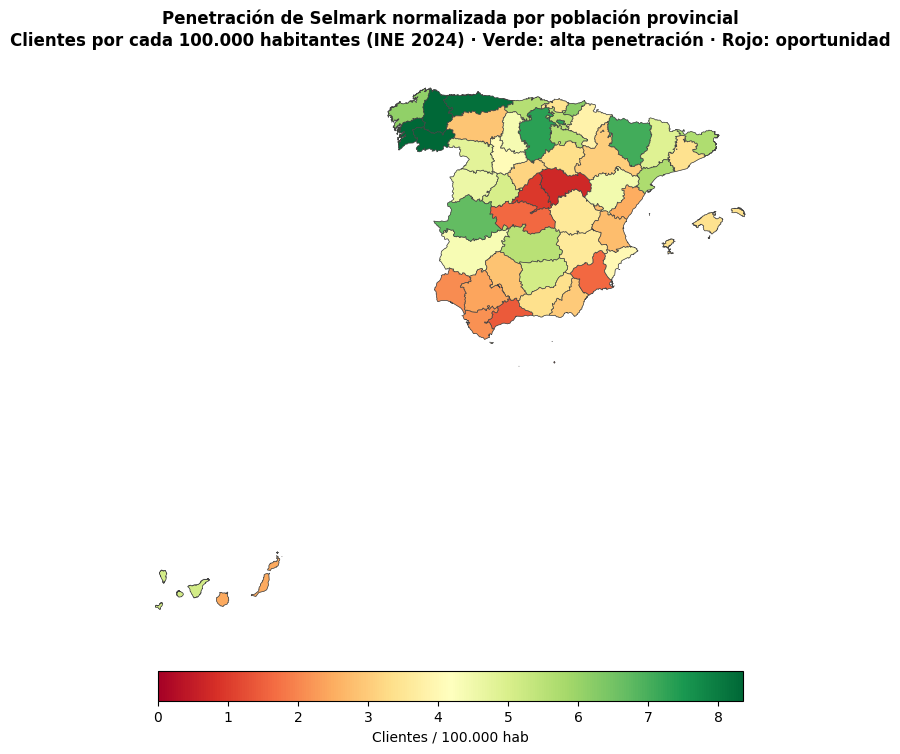

   Figura guardada PNG: 12_choropleth_penetracion.png


In [20]:
# Choropleth de penetración (clientes/100K hab) con matplotlib + geopandas
# Re-merge para incluir las columnas calculadas más recientemente
gdf_merged = gdf.merge(top_provincias, left_on="name_norm", right_on="provincia_norm", how="left")

fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
gdf_merged.plot(ax=ax, color="#EEEEEE", edgecolor="#999999", linewidth=0.4)
gdf_datos = gdf_merged[gdf_merged["clientes_por_100k_hab"].notna()].copy()
vmax = gdf_datos["clientes_por_100k_hab"].quantile(0.95)
gdf_datos.plot(
    ax=ax, column="clientes_por_100k_hab", cmap="RdYlGn", legend=True,
    legend_kwds={"label": "Clientes / 100.000 hab", "orientation": "horizontal",
                  "shrink": 0.5, "pad": 0.05},
    edgecolor="#444444", linewidth=0.5, vmin=0, vmax=vmax,
)
ax.set_title("Penetración de Selmark normalizada por población provincial\n"
              "Clientes por cada 100.000 habitantes (INE 2024) · Verde: alta penetración · Rojo: oportunidad",
              fontsize=12, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
ruta_png = RUTA_FIGURAS / "12_choropleth_penetracion.png"
plt.savefig(str(ruta_png), dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   Figura guardada PNG: {ruta_png.name}")

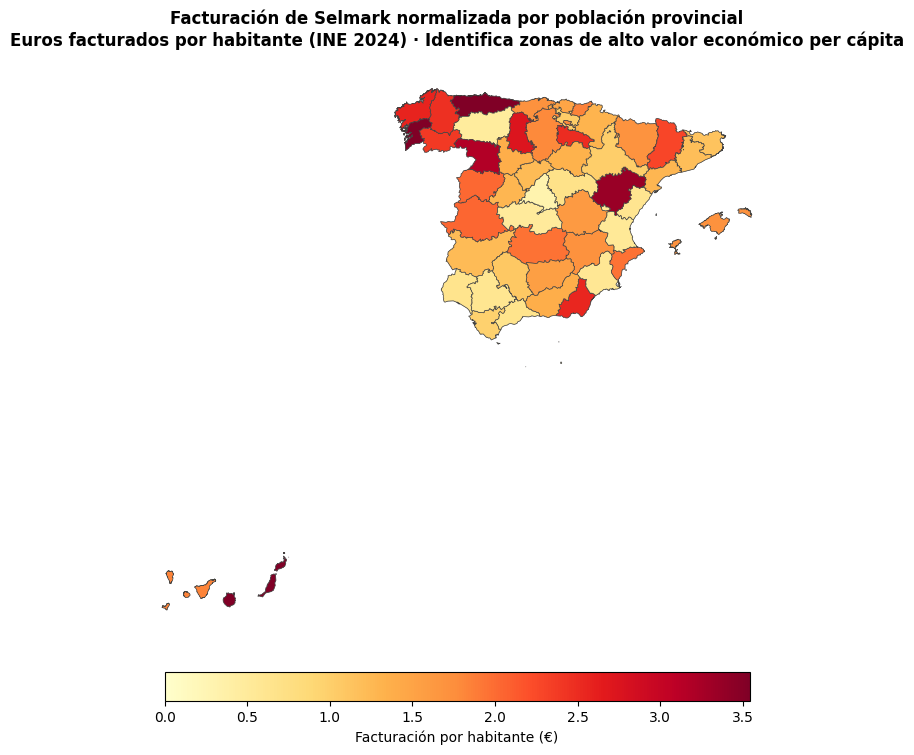

   Figura guardada PNG: 13_choropleth_fact_per_capita.png


In [21]:
# Choropleth de € per cápita con matplotlib + geopandas
fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
gdf_merged.plot(ax=ax, color="#EEEEEE", edgecolor="#999999", linewidth=0.4)
gdf_datos = gdf_merged[gdf_merged["facturacion_per_capita_eur"].notna()].copy()
vmax = gdf_datos["facturacion_per_capita_eur"].quantile(0.95)
gdf_datos.plot(
    ax=ax, column="facturacion_per_capita_eur", cmap="YlOrRd", legend=True,
    legend_kwds={"label": "Facturación por habitante (€)", "orientation": "horizontal",
                  "shrink": 0.5, "pad": 0.05, "format": "%.1f"},
    edgecolor="#444444", linewidth=0.5, vmin=0, vmax=vmax,
)
ax.set_title("Facturación de Selmark normalizada por población provincial\n"
              "Euros facturados por habitante (INE 2024) · Identifica zonas de alto valor económico per cápita",
              fontsize=12, fontweight="bold", pad=12)
ax.set_axis_off()
plt.tight_layout()
ruta_png = RUTA_FIGURAS / "13_choropleth_fact_per_capita.png"
plt.savefig(str(ruta_png), dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"   Figura guardada PNG: {ruta_png.name}")

### Lectura comparativa de los dos choropleth per cápita

La comparación entre los dos mapas normalizados (penetración de clientes y facturación per cápita) permite identificar matices estratégicos adicionales que ninguna de las dos métricas captura por sí sola. La penetración (clientes por cada 100.000 habitantes) mide cuán extendida está la cartera en el territorio en términos de densidad de relaciones comerciales, mientras que la facturación per cápita (euros facturados por habitante) mide cuánto valor económico genera Selmark por cada habitante del territorio.

Pontevedra ocupa la primera posición en ambos rankings (8,67 clientes/100K hab y 4,57 €/habitante), lo que la consolida como el mercado más maduro y de mayor valor de la cartera nacional. Las Palmas, en cambio, no aparece entre las primeras provincias por penetración (28 clientes solamente) pero sí ocupa la segunda posición por facturación per cápita (4,32 €/habitante), patrón coherente con la presencia de pocos clientes pero de muy alto valor (la facturación media por cliente en Las Palmas es de 176.000 €, una de las más altas de la cartera nacional).

Algunas provincias castellano-leonesas pequeñas como Teruel, Zamora y Palencia muestran un patrón similar a Las Palmas pero atenuado: pocos clientes con ticket relativamente alto en relación con su tamaño poblacional reducido. Este patrón sugiere la existencia de distribuidores comarcales bien posicionados en mercados pequeños donde Selmark mantiene una cuota local elevada.

### Lectura comparativa: penetración absoluta vs per cápita

La comparación entre el ranking por número de clientes y el ranking por penetración normalizada revela el contraste estratégico entre mercados maduros y mercados infraexplotados. Las provincias del cuadrante noroeste peninsular (Asturias, Pontevedra, A Coruña, Lugo) y las islas (Baleares, Santa Cruz de Tenerife) presentan penetraciones superiores a 6 clientes por cada 100.000 habitantes, valores que indican una presencia comercial consolidada y un mercado próximo a la saturación natural. Esta concentración geográfica del negocio en el cuadrante noroeste es coherente con la ubicación histórica de la sede empresarial de Selmark en Galicia y con la dinámica habitual de las empresas familiares del sector retail que parten de su mercado regional original.

En el extremo opuesto, las grandes capitales con mercado muy poblado pero penetración reducida (Madrid con 1,0 clientes/100K hab; Málaga con valores similares; Sevilla por debajo de 3) representan la principal oportunidad estratégica de la cartera nacional. Madrid en particular, siendo el mayor mercado potencial de España con más de 7 millones de habitantes, presenta una penetración seis veces inferior a la media nacional, lo que sugiere un potencial de captación significativo si se asignan recursos comerciales específicos. Esta lectura, oculta en el ranking absoluto donde Madrid figura simplemente como una provincia más entre las quince primeras, constituye uno de los hallazgos estratégicos clave del análisis geomarketing del Capítulo 6 y motivará varias de las recomendaciones del Capítulo 8.

## 3. Análisis a nivel de código postal

El análisis a nivel de código postal proporciona la resolución geográfica más fina del estudio. Los 1.901 clientes nacionales se distribuyen entre 1.199 códigos postales únicos, lo que equivale a una media de 1,59 clientes por CP. Esta dispersión es alta: salvo en concentraciones urbanas específicas, la mayoría de códigos postales tiene un único cliente Selmark, lo que sugiere una distribución bastante uniforme dentro de cada provincia. Las concentraciones máximas se sitúan en torno a 5-6 clientes por CP en zonas urbanas medias como Zaragoza centro (50003), Ávila (05001), Reus (43201), Sevilla centro (41004) y Lugo capital (27004), todas ellas capitales de provincia o ciudades comarcales relevantes.

La visualización mediante el mapa interactivo de Folium con marcadores agrupados (MarkerCluster) facilita la exploración visual de esta distribución a múltiples niveles de zoom: al alejar la vista los marcadores se agrupan en cifras agregadas por región, mientras que al hacer zoom progresivo se desagregan hasta mostrar clientes individuales con sus datos asociados en el tooltip.

In [22]:
# Top 25 códigos postales por número de clientes
top_cp = df_nac[df_nac["cp"].notna()].copy()
# Asegurar que cp es string con 5 caracteres
top_cp["cp"] = top_cp["cp"].astype(str).str.zfill(5)

resumen_cp = (top_cp.groupby(["cp", "ciudad", "provincia"]).agg(
    n_clientes=("id_cliente", "count"),
    facturacion_total=("facturacion_combinada", "sum"),
).reset_index())
resumen_cp = resumen_cp.sort_values("n_clientes", ascending=False).reset_index(drop=True)

print(f"NÚMERO DE CÓDIGOS POSTALES DIFERENTES: {len(resumen_cp):,}")
print(f"\nTOP 25 CÓDIGOS POSTALES POR NÚMERO DE CLIENTES:")
print("=" * 100)
print(resumen_cp.head(25).to_string())

NÚMERO DE CÓDIGOS POSTALES DIFERENTES: 1,199

TOP 25 CÓDIGOS POSTALES POR NÚMERO DE CLIENTES:
       cp                 ciudad               provincia  n_clientes  facturacion_total
0   05001                  AVILA                   Ávila           6          159409.78
1   50003               ZARAGOZA                Zaragoza           6          192551.84
2   27004                   LUGO                    Lugo           5          137288.13
3   36001             PONTEVEDRA              Pontevedra           5          219438.84
4   41004                SEVILLA                 Sevilla           5          310290.54
5   43201                   REUS               Tarragona           5           93138.27
6   06300                  ZAFRA                 Badajoz           5           32258.62
7   08030              BARCELONA               Barcelona           5           12629.03
8   26580                 ARNEDO                La Rioja           5           84617.18
9   17200            PALAF

In [23]:
# Visualización: Top 25 códigos postales
top25_cp = resumen_cp.head(25).copy()
top25_cp["etiqueta"] = top25_cp["cp"] + " - " + top25_cp["ciudad"].fillna("")
top25_cp = top25_cp.sort_values("n_clientes", ascending=True)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=top25_cp["n_clientes"], y=top25_cp["etiqueta"],
    orientation="h",
    marker=dict(color=top25_cp["facturacion_total"], colorscale="YlOrRd",
                  colorbar=dict(title="Facturación (€)", thickness=12)),
    text=[fmt_es(v) for v in top25_cp["n_clientes"]],
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Clientes: %{x}<br>Facturación: %{marker.color:,.0f} €<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>Top 25 códigos postales por número de clientes</b><br><sup>Color de cada barra: facturación total acumulada en ese CP</sup>"),
    xaxis_title="Número de clientes",
    height=750, margin=dict(l=180),
)
guardar_y_mostrar(fig, "05_top25_cp", h=750)

   AVISO: no se pudo exportar 05_top25_cp.png (JavascriptError). Continuando.


### Mapa interactivo de clientes nacionales (Folium)

In [24]:
# Generar mapa interactivo con folium si está disponible
# Como no tenemos coordenadas latitud/longitud en gold.cliente_360, agregamos por CP usando un join
# aproximado mediante centroides de provincia. Para un análisis más fino, sería necesario un geocoding
# previo de los CPs (fuera del alcance de este TFG).

if FOLIUM_OK:
    # Diccionario de centroides aproximados de las 20 provincias con más clientes
    # (suficiente para una visualización indicativa)
    CENTROIDES_PROV = {
        "MADRID":               (40.4168, -3.7038),
        "BARCELONA":            (41.3851, 2.1734),
        "VALENCIA":             (39.4699, -0.3763),
        "SEVILLA":              (37.3886, -5.9823),
        "MALAGA":               (36.7213, -4.4214),
        "ALICANTE":             (38.3452, -0.4810),
        "MURCIA":               (37.9922, -1.1307),
        "PALMA DE MALLORCA":    (39.5696, 2.6502),
        "BALEARES":             (39.5696, 2.6502),
        "BIZKAIA":              (43.2627, -2.9253),
        "VIZCAYA":              (43.2627, -2.9253),
        "GIPUZKOA":             (43.3128, -1.9748),
        "GUIPUZCOA":             (43.3128, -1.9748),
        "ZARAGOZA":             (41.6488, -0.8891),
        "CADIZ":                (36.5298, -6.2924),
        "GRANADA":               (37.1773, -3.5986),
        "PONTEVEDRA":           (42.4310, -8.6444),
        "A CORUNA":              (43.3623, -8.4115),
        "CORUNA":                (43.3623, -8.4115),
        "ASTURIAS":              (43.3614, -5.8593),
        "CANTABRIA":             (43.4623, -3.8099),
        "CORDOBA":               (37.8882, -4.7794),
        "TENERIFE":              (28.4636, -16.2518),
        "SANTA CRUZ DE TENERIFE": (28.4636, -16.2518),
        "LAS PALMAS":            (28.1235, -15.4363),
    }
    
    # Crear mapa centrado en España
    mapa = folium.Map(location=[40.0, -3.5], zoom_start=6, tiles="cartodbpositron")
    cluster_marcadores = MarkerCluster(name="Clientes").add_to(mapa)
    
    # Añadir un marcador por cada provincia con jitter aleatorio
    np.random.seed(42)
    df_nac_geo = df_nac.copy()
    df_nac_geo["prov_norm"] = df_nac_geo["provincia"].apply(normalizar_provincia)
    
    contador = 0
    for _, row in df_nac_geo.iterrows():
        prov = row["prov_norm"]
        if prov not in CENTROIDES_PROV:
            continue
        lat0, lon0 = CENTROIDES_PROV[prov]
        # Jitter pequeño para que los marcadores no se solapen
        lat = lat0 + np.random.uniform(-0.15, 0.15)
        lon = lon0 + np.random.uniform(-0.15, 0.15)
        
        popup_html = f"""
        <b>Cliente {row['id_cliente']}</b><br>
        Cluster: <b>{row.get('cluster_nombre', 'n/a')}</b><br>
        Provincia: {row['provincia']}<br>
        Ciudad: {row.get('ciudad', 'n/a')}<br>
        Facturación: {row['facturacion_combinada']:,.0f} €
        """
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            popup=folium.Popup(popup_html, max_width=300),
            color=COLOR_NACIONAL, fill=True, fill_opacity=0.7,
        ).add_to(cluster_marcadores)
        contador += 1
    
    # Guardar como HTML
    ruta_mapa = RUTA_FIGURAS / "06_mapa_interactivo_nacional.html"
    mapa.save(str(ruta_mapa))
    print(f"   Mapa interactivo guardado en: {ruta_mapa.name}")
    print(f"   Total marcadores añadidos: {contador:,}")
    
    # Mostrar el mapa en el notebook
    from IPython.display import display, IFrame
    display(IFrame(src=str(ruta_mapa), width=950, height=550))
else:
    print("Folium no disponible. Saltando la generación del mapa interactivo.")

   Mapa interactivo guardado en: 06_mapa_interactivo_nacional.html
   Total marcadores añadidos: 1,098


## 4. Distribución internacional por país

El mercado internacional concentra el 38,4 % de la cartera (1.183 clientes) repartidos entre 48 países, lo que evidencia la dimensión global del negocio de Selmark. La distribución internacional presenta dos patrones diferenciados con implicaciones estratégicas distintas. Por un lado, mercados de penetración de masa con muchos clientes y ticket medio, como Italia (528 clientes que aportan 8,74 M€, equivalente a 16.550 € por cliente) y Polonia (75 clientes con 26.844 € de ticket medio). Por otro lado, mercados de cuenta única o muy concentrada con uno o pocos clientes pero ticket muy elevado, como Israel (1 cliente con 4,82 M€), México (3 clientes con 4,81 M€ totales y 1,6 M€ por cliente), Reino Unido (5 clientes con 4,62 M€) o Rusia (3 clientes con 3,63 M€).

El primer país de la cartera internacional por facturación es Portugal, que combina ambos patrones: 301 clientes (25,4 % del total internacional) que aportan 15,54 M€ (25,9 % de la facturación internacional), con un ticket medio de 51.623 €. Esta dimensión hace de Portugal el principal mercado internacional de Selmark tanto en volumen como en valor económico, coherente con su proximidad geográfica, cultural y lingüística al mercado español.

La codificación ISO 3166 alpha-3 utilizada para los mapas coropléticos mundiales se aplica mediante la librería `pycountry` con un diccionario complementario de equivalencias para nombres en castellano. Nueve países (mayoritariamente con un único cliente) no encuentran equivalencia y se documentan como limitación menor del análisis, sin impacto material en las conclusiones dado que en conjunto representan menos del 4 % de los clientes internacionales.

In [25]:
# Distribución por país (solo internacionales)
resumen_pais = (df_int.groupby("pais").agg(
    n_clientes=("id_cliente", "count"),
    facturacion_total=("facturacion_combinada", "sum"),
).reset_index())
resumen_pais["pct_clientes"] = (100 * resumen_pais["n_clientes"] / resumen_pais["n_clientes"].sum()).round(2)
resumen_pais["pct_facturacion"] = (100 * resumen_pais["facturacion_total"] / resumen_pais["facturacion_total"].sum()).round(2)
resumen_pais["facturacion_media_por_cliente"] = (resumen_pais["facturacion_total"] / resumen_pais["n_clientes"]).round(0)
resumen_pais = resumen_pais.sort_values("facturacion_total", ascending=False).reset_index(drop=True)

print(f"NÚMERO DE PAÍSES INTERNACIONALES CON CLIENTES: {len(resumen_pais)}")
print(f"\nDISTRIBUCIÓN INTERNACIONAL POR PAÍS (TOP 20):")
print("=" * 110)
print(resumen_pais.head(20).to_string())

NÚMERO DE PAÍSES INTERNACIONALES CON CLIENTES: 48

DISTRIBUCIÓN INTERNACIONAL POR PAÍS (TOP 20):
               pais  n_clientes  facturacion_total  pct_clientes  pct_facturacion  facturacion_media_por_cliente
0          Portugal         301        15538613.27         25.44            25.90                        51623.0
1            Italia         528         8738510.89         44.63            14.57                        16550.0
2            Israel           1         4815763.90          0.08             8.03                      4815764.0
3            México           3         4811428.85          0.25             8.02                      1603810.0
4       Reino Unido           5         4620008.66          0.42             7.70                       924002.0
5             Rusia           3         3631750.56          0.25             6.05                      1210584.0
6           Bélgica          50         3019536.99          4.23             5.03                        60391.0

In [26]:
# Top 15 países: barras dobles (clientes vs facturación)
top15_paises = resumen_pais.head(15).sort_values("facturacion_total", ascending=True)

fig = make_subplots(rows=1, cols=2,
                     subplot_titles=("Número de clientes por país",
                                      "Facturación total por país (€)"),
                     shared_yaxes=True, horizontal_spacing=0.10)

fig.add_trace(go.Bar(
    x=top15_paises["n_clientes"], y=top15_paises["pais"],
    orientation="h", marker_color=COLOR_INTERNACIONAL,
    text=[fmt_es(v) for v in top15_paises["n_clientes"]], textposition="outside",
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Bar(
    x=top15_paises["facturacion_total"], y=top15_paises["pais"],
    orientation="h", marker_color=COLOR_DESTACAR,
    text=[f"{v/1e6:.1f}M€" for v in top15_paises["facturacion_total"]],
    textposition="outside", showlegend=False,
), row=1, col=2)

fig.update_layout(
    title=dict(text="<b>Top 15 países por dimensión comercial</b><br><sup>Mercado internacional: número de clientes (izquierda) y facturación total (derecha)</sup>"),
    height=600,
)
guardar_y_mostrar(fig, "07_top15_paises", h=600)

   AVISO: no se pudo exportar 07_top15_paises.png (JavascriptError). Continuando.


In [27]:
%pip install pycountry

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Choropleth mundial con plotly
# Plotly usa ISO 3 country codes; aplicamos el mapeo desde el nombre
import pycountry

def pais_a_iso3(nombre):
    """Convierte un nombre de país a su código ISO Alpha-3."""
    if pd.isna(nombre):
        return None
    try:
        c = pycountry.countries.search_fuzzy(str(nombre))
        if c:
            return c[0].alpha_3
    except LookupError:
        return None
    return None

# Mapeos manuales para nombres frecuentes en español
ISO3_ES = {
    "PORTUGAL": "PRT", "FRANCIA": "FRA", "ITALIA": "ITA", "ALEMANIA": "DEU",
    "REINO UNIDO": "GBR", "BELGICA": "BEL", "PAISES BAJOS": "NLD", "HOLANDA": "NLD",
    "GRECIA": "GRC", "RUSIA": "RUS", "ESTADOS UNIDOS": "USA", "EEUU": "USA",
    "JAPON": "JPN", "CHINA": "CHN", "INDIA": "IND", "BRASIL": "BRA", "MEXICO": "MEX",
    "ARGENTINA": "ARG", "CHILE": "CHL", "COLOMBIA": "COL", "PERU": "PER",
    "POLONIA": "POL", "REPUBLICA CHECA": "CZE", "RUMANIA": "ROU", "BULGARIA": "BGR",
    "TURQUIA": "TUR", "ARABIA SAUDI": "SAU", "EMIRATOS ARABES UNIDOS": "ARE",
    "MARRUECOS": "MAR", "TUNEZ": "TUN", "ARGELIA": "DZA", "EGIPTO": "EGY",
    "SUDAFRICA": "ZAF", "AUSTRALIA": "AUS", "ANDORRA": "AND", "SUIZA": "CHE",
    "AUSTRIA": "AUT", "IRLANDA": "IRL", "LUXEMBURGO": "LUX", "DINAMARCA": "DNK",
    "SUECIA": "SWE", "NORUEGA": "NOR", "FINLANDIA": "FIN", "ISLANDIA": "ISL",
}

def obtener_iso3(nombre):
    if pd.isna(nombre):
        return None
    n = normalizar_provincia(nombre)  # reutilizamos el normalizador
    if n in ISO3_ES:
        return ISO3_ES[n]
    return pais_a_iso3(nombre)

resumen_pais["iso3"] = resumen_pais["pais"].apply(obtener_iso3)

# Reportar países sin ISO3
sin_iso = resumen_pais[resumen_pais["iso3"].isna()]
if len(sin_iso) > 0:
    print(f"AVISO: {len(sin_iso)} países sin código ISO3 (no se colorearán en el mapa):")
    print(sin_iso[["pais", "n_clientes"]].to_string())

AVISO: 9 países sin código ISO3 (no se colorearán en el mapa):
                    pais  n_clientes
12       Sin identificar          31
20              Lituania           1
22                Líbano           2
23                Chipre           2
28              Moldavia           2
30  República Dominicana           1
37             Eslovenia           1
42  Bélgica/Países Bajos           2
43            Kirguistán           1


In [29]:
# Choropleth mundial: clientes
fig = px.choropleth(
    resumen_pais[resumen_pais["iso3"].notna()],
    locations="iso3",
    color="n_clientes",
    hover_name="pais",
    color_continuous_scale="Blues",
    range_color=(0, resumen_pais["n_clientes"].quantile(0.95)),
    labels={"n_clientes": "Clientes"},
    hover_data={"facturacion_total": ":,.0f", "iso3": False},
)
fig.update_layout(
    title=dict(text="<b>Distribución internacional de clientes</b><br><sup>Choropleth mundial de clientes Selmark fuera de España · Escala recortada al P95</sup>"),
    height=550, geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    margin=dict(l=20, r=20, t=80, b=20),
)
guardar_y_mostrar(fig, "08_choropleth_mundial_clientes", h=550)

   AVISO: no se pudo exportar 08_choropleth_mundial_clientes.png (JavascriptError). Continuando.


In [30]:
# Choropleth mundial: facturación
fig = px.choropleth(
    resumen_pais[resumen_pais["iso3"].notna()],
    locations="iso3",
    color="facturacion_total",
    hover_name="pais",
    color_continuous_scale="YlGnBu",
    range_color=(0, resumen_pais["facturacion_total"].quantile(0.95)),
    labels={"facturacion_total": "Facturación (€)"},
    hover_data={"n_clientes": True, "facturacion_total": ":,.0f", "iso3": False},
)
fig.update_layout(
    title=dict(text="<b>Distribución internacional de la facturación</b><br><sup>Total facturado 4 años (B2B + retail) · Escala recortada al P95</sup>"),
    height=550, geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    margin=dict(l=20, r=20, t=80, b=20),
)
guardar_y_mostrar(fig, "09_choropleth_mundial_facturacion", h=550)

   AVISO: no se pudo exportar 09_choropleth_mundial_facturacion.png (JavascriptError). Continuando.


### Hallazgo internacional: los clientes "monstruo"

Los mapas coropléticos mundiales revelan la existencia de seis países en los que Selmark mantiene exclusivamente entre uno y cinco clientes pero con facturaciones que oscilan entre 1 millón y 5 millones de euros: Israel (1 cliente, 4,82 M€), Kuwait (1 cliente, 1,26 M€), República Checa (1 cliente, 1,02 M€), Reino Unido (5 clientes, 4,62 M€), México (3 clientes, 4,81 M€) y Rusia (3 clientes, 3,63 M€). Estos clientes, denominados aquí "monstruo" por su desproporcionado peso económico individual, son con alta probabilidad parte del Cluster 2 (Grandes Cuentas Internacionales) identificado en el Capítulo 5, donde la facturación media por cliente alcanzaba los 282.555 € y la composición internacional superaba el 60 %.

La concentración de la facturación en pocos clientes en estos mercados implica un riesgo comercial elevado: la pérdida de un único distribuidor en Israel o Kuwait equivaldría a una caída perceptible en la cuenta de resultados consolidada. Esta concentración refuerza la necesidad de las estrategias de retención específicas para grandes cuentas que se desarrollarán en el Capítulo 8 del TFG, así como la prudencia en la dependencia de canal individual.

## 5. Síntesis y conexión con el notebook 12b

El notebook 12a ha desarrollado la primera parte del análisis geomarketing del Capítulo 6 del TFG mediante tres dimensiones complementarias: distribución provincial nacional, agregación por Comunidad Autónoma, análisis a nivel de código postal en las concentraciones urbanas, y distribución internacional por país. Los principales hallazgos del análisis se sintetizan en cinco bloques diferenciados.

En primer lugar, **la regla del Pareto aplicada al territorio**: 9 provincias (el 17,3 % del total) concentran el 50 % de la facturación nacional, y 25 provincias (el 48,1 %) concentran el 80 %. Esta concentración refleja a nivel territorial la misma asimetría observada a nivel de cliente en el Capítulo 5.

En segundo lugar, **el patrón noroeste peninsular**: Galicia y Asturias concentran las cuatro primeras posiciones del ranking de penetración por habitante (Lugo, Pontevedra, Ourense y Asturias, todas con valores superiores a 8 clientes por cada 100.000 habitantes), coherente con la ubicación histórica de la sede de Selmark en Galicia.

En tercer lugar, **la oportunidad de Madrid**: con apenas 0,97 clientes por cada 100.000 habitantes (nueve veces menos que Lugo), Madrid emerge como el mercado infraexplotado más relevante de España, con un potencial de captación de varios cientos de clientes adicionales si se acercara siquiera a la media nacional.

En cuarto lugar, **el caso Canarias**: con solo el 4,9 % de los clientes nacionales aporta el 10,6 % de la facturación nacional, perfil característico de cartera concentrada en clientes de alto valor (probablemente Cluster 2 o Cluster 1 del Capítulo 5).

En quinto lugar, **la concentración internacional en Portugal y los clientes "monstruo"**: Portugal lidera el mercado internacional con 15,54 M€ (25,9 % de la facturación internacional), pero seis países adicionales (Israel, Kuwait, México, Reino Unido, Rusia, República Checa) presentan cifras millonarias con uno a cinco clientes cada uno, perfil característico de Grandes Cuentas que requieren atención individualizada.

Los datasets agregados generados (`geomarketing_provincias.parquet` y `geomarketing_paises.parquet`) constituyen la entrada del notebook 12b, donde se cruza esta distribución geográfica con los seis clusters identificados en el notebook 11b. El notebook 12b desarrollará cuatro análisis adicionales: distribución de cada cluster por provincia y país, mapas con cluster dominante por territorio, penetración per cápita segmentada por cluster, e identificación de huecos territoriales (provincias con baja penetración pero perfil demográfico compatible con los clusters de mayor valor económico).

In [31]:
# Síntesis final del notebook 12a
print(f"\n" + "=" * 100)
print(f"SÍNTESIS DEL NOTEBOOK 12a — DISTRIBUCIÓN GEOGRÁFICA")
print("=" * 100)

print(f"\n1. PERÍMETRO ANALIZADO")
print(f"   Clientes nacionales:       {len(df_nac):>5,}")
print(f"   Clientes internacionales:  {len(df_int):>5,}")
print(f"   TOTAL:                     {len(df):>5,}")

print(f"\n2. DISTRIBUCIÓN NACIONAL")
print(f"   Provincias con clientes:   {len(top_provincias):>5,}")
print(f"   Códigos postales únicos:    {len(resumen_cp):>5,}")
print(f"   Top 5 provincias por facturación:")
for _, row in top_provincias_ordenado.head(5).iterrows():
    print(f"      {row['provincia']:<25s}  {fmt_es(row['n_clientes']):>5} clientes  ({row['pct_clientes']:.1f}%)  ·  {row['facturacion_total']/1e6:.2f} M€  ({row['pct_facturacion']:.1f}%)")

print(f"\n3. DISTRIBUCIÓN INTERNACIONAL")
print(f"   Países con clientes:       {len(resumen_pais):>5,}")
print(f"   Top 5 países por facturación:")
for _, row in resumen_pais.head(5).iterrows():
    print(f"      {row['pais']:<25s}  {fmt_es(row['n_clientes']):>5} clientes  ({row['pct_clientes']:.1f}%)  ·  {row['facturacion_total']/1e6:.2f} M€  ({row['pct_facturacion']:.1f}%)")

print(f"\n4. CONEXIÓN CON NOTEBOOK 12b")
print(f"   En el notebook 12b se cruzará esta distribución geográfica con los 6 segmentos")
print(f"   identificados en el notebook 11b, mediante:")
print(f"      - Distribución de cada cluster por provincia y país")
print(f"      - Mapa con cluster dominante por provincia")
print(f"      - Penetración per cápita por cluster (clientes/100K hab por segmento)")
print(f"      - Identificación de huecos territoriales: provincias con baja penetración")
print(f"        pero perfil demográfico compatible con los clusters de mayor valor")

# Guardar datasets agregados para el notebook 12b
ruta_provincias = RUTA_PROYECTO / "output" / "geomarketing_provincias.parquet"
ruta_paises     = RUTA_PROYECTO / "output" / "geomarketing_paises.parquet"
top_provincias.to_parquet(ruta_provincias, index=False)
resumen_pais.to_parquet(ruta_paises, index=False)
print(f"\n5. ARCHIVOS EXPORTADOS PARA EL NOTEBOOK 12b:")
print(f"   {ruta_provincias.name}: {len(top_provincias):,} provincias")
print(f"   {ruta_paises.name}: {len(resumen_pais):,} países")

print(f"\n" + "=" * 100)
print(f"CIERRE DEL NOTEBOOK 12a · Listos para el notebook 12b (cruce con clusters)")
print(f"Figuras generadas: {len(list(RUTA_FIGURAS.glob('*.png')))} PNG + {len(list(RUTA_FIGURAS.glob('*.html')))} HTML interactivos")
print("=" * 100)


SÍNTESIS DEL NOTEBOOK 12a — DISTRIBUCIÓN GEOGRÁFICA

1. PERÍMETRO ANALIZADO
   Clientes nacionales:       1,901
   Clientes internacionales:  1,183
   TOTAL:                     3,084

2. DISTRIBUCIÓN NACIONAL
   Provincias con clientes:      52
   Códigos postales únicos:    1,199
   Top 5 provincias por facturación:
      Barcelona                    195 clientes  (11.7%)  ·  6.79 M€  (10.5%)
      Las Palmas                    28 clientes  (1.7%)  ·  4.94 M€  (7.6%)
      Pontevedra                    83 clientes  (5.0%)  ·  4.37 M€  (6.8%)
      Alicante                      78 clientes  (4.7%)  ·  3.81 M€  (5.9%)
      Asturias                      83 clientes  (5.0%)  ·  3.81 M€  (5.9%)

3. DISTRIBUCIÓN INTERNACIONAL
   Países con clientes:          48
   Top 5 países por facturación:
      Portugal                     301 clientes  (25.4%)  ·  15.54 M€  (25.9%)
      Italia                       528 clientes  (44.6%)  ·  8.74 M€  (14.6%)
      Israel                         1 c

In [32]:
con.close()
print("Conexión a DuckDB cerrada. Notebook 12a completado.")

Conexión a DuckDB cerrada. Notebook 12a completado.
